## Import the dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load and inspect the dataset

In [2]:
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_country_df = pd.read_csv ('../data/raw/IpAddress_to_Country.csv')

In [3]:
print(fraud_df.head())
## fraud_df.ip_address.dtypes
## fraud_df.signup_time.dtypes
##print(ip_country_df.head())
## print(fraud_df.info())
## print(fraud_df.shape)

   user_id          signup_time        purchase_time  purchase_value  \
0    22058  2015-02-24 22:55:49  2015-04-18 02:47:11              34   
1   333320  2015-06-07 20:39:50  2015-06-08 01:38:54              16   
2     1359  2015-01-01 18:52:44  2015-01-01 18:52:45              15   
3   150084  2015-04-28 21:13:25  2015-05-04 13:54:50              44   
4   221365  2015-07-21 07:09:52  2015-09-09 18:40:53              39   

       device_id source browser sex  age    ip_address  class  
0  QVPSPJUOCKZAR    SEO  Chrome   M   39  7.327584e+08      0  
1  EOGFQPIZPYXFZ    Ads  Chrome   F   53  3.503114e+08      0  
2  YSSKYOSJHPPLJ    SEO   Opera   M   53  2.621474e+09      1  
3  ATGTXKYKUDUQN    SEO  Safari   M   41  3.840542e+09      0  
4  NAUITBZFJKHWW    Ads  Safari   M   45  4.155831e+08      0  


# 2. Data Cleaning

### 2.1. Missing value checks

In [4]:
print(fraud_df.isnull().sum())
print(fraud_df.isin(['', ' ', 'NaN', 'null']).sum())


user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64


### 2.2. Duplicates

In [5]:
# Duplicates
print("Duplicate rows:", fraud_df.duplicated().sum())
print("Duplicate user_ids:", fraud_df['user_id'].duplicated().sum())

Duplicate rows: 0
Duplicate user_ids: 0


### 2.3. Data Types

In [6]:
print(fraud_df.dtypes)

user_id             int64
signup_time        object
purchase_time      object
purchase_value      int64
device_id          object
source             object
browser            object
sex                object
age                 int64
ip_address        float64
class               int64
dtype: object


In [7]:
# Fix dtypes
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])
fraud_df['ip_address'] = fraud_df['ip_address'].astype('int64')

ip_country_df['lower_bound_ip_address'] = (
    ip_country_df['lower_bound_ip_address'].astype('int64')
)

ip_country_df['upper_bound_ip_address'] = (
    ip_country_df['upper_bound_ip_address'].astype('int64')
)
print(fraud_df.dtypes)
print(ip_country_df.dtypes)

user_id                    int64
signup_time       datetime64[ns]
purchase_time     datetime64[ns]
purchase_value             int64
device_id                 object
source                    object
browser                   object
sex                       object
age                        int64
ip_address                 int64
class                      int64
dtype: object
lower_bound_ip_address     int64
upper_bound_ip_address     int64
country                   object
dtype: object


# 3. Exploratory Data Analysis (EDA)

### 3.1 Univariate Analysis
 - The key variable that I am going to consider are purchase_value, age, and source (browser). Why?
     - Skew in purchase_value and Amount — fraud transactions often sit at the unusual extremes (very small "test" charges or unusually large ones), so if the distribution has a long tail, that tail is worth a second look later in bivariate analysis.
     - Spread and range in age — are there implausible values (e.g. age 0 or age 120)? That's a data quality flag, not just a shape observation.
     - Category dominance in source and browser — if 95% of all traffic comes through one browser, then "browser" alone won't discriminate fraud well; if it's more balanced, it might carry real signal.

In [8]:
print(fraud_df[['purchase_value' , 'age']].describe())

       purchase_value            age
count   151112.000000  151112.000000
mean        36.935372      33.140704
std         18.322762       8.617733
min          9.000000      18.000000
25%         22.000000      27.000000
50%         35.000000      33.000000
75%         49.000000      39.000000
max        154.000000      76.000000


In [9]:
print(fraud_df['source'].value_counts())

source
SEO       60615
Ads       59881
Direct    30616
Name: count, dtype: int64


In [10]:
print(fraud_df['sex'].value_counts())

sex
M    88293
F    62819
Name: count, dtype: int64


       purchase_value            age
count   151112.000000  151112.000000
mean        36.935372      33.140704
std         18.322762       8.617733
min          9.000000      18.000000
25%         22.000000      27.000000
50%         35.000000      33.000000
75%         49.000000      39.000000
max        154.000000      76.000000


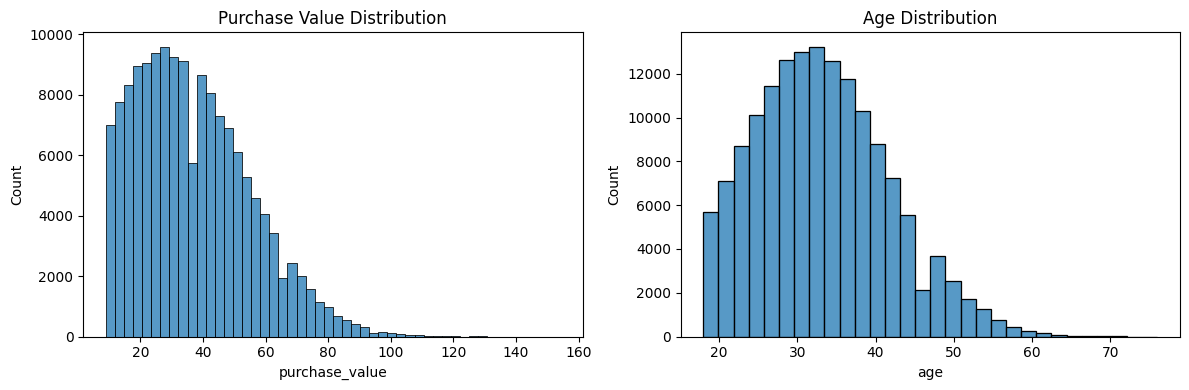

source
SEO       60615
Ads       59881
Direct    30616
Name: count, dtype: int64
browser
Chrome     61432
IE         36727
Safari     24667
FireFox    24610
Opera       3676
Name: count, dtype: int64
sex
M    88293
F    62819
Name: count, dtype: int64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric summary
print(fraud_df[['purchase_value', 'age']].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(fraud_df['purchase_value'], bins=50, ax=axes[0])
axes[0].set_title('Purchase Value Distribution')
sns.histplot(fraud_df['age'], bins=30, ax=axes[1])
axes[1].set_title('Age Distribution')
plt.tight_layout()
plt.show()

# Categorical counts
print(fraud_df['source'].value_counts())
print(fraud_df['browser'].value_counts())
print(fraud_df['sex'].value_counts())

## 3.2 Bivariate Analysis

In [12]:
print(fraud_df['class'].value_counts())
print(fraud_df['class'].value_counts(normalize=True) * 100)

class
0    136961
1     14151
Name: count, dtype: int64
class
0    90.635423
1     9.364577
Name: proportion, dtype: float64


In [13]:
# Fraud rate by numerical columns - Purchase_value & age by class
print(fraud_df.groupby('class')[['purchase_value', 'age']].mean())
print(fraud_df.groupby('class')[['purchase_value', 'age']].median())

       purchase_value        age
class                           
0           36.929418  33.122356
1           36.993004  33.318281
       purchase_value   age
class                      
0                35.0  33.0
1                35.0  33.0


In [14]:
# fraud RATE by category - source, browser, sex but here mean() usage is different from the above. U can c the syntax
print(fraud_df.groupby('source')['class'].mean())

print(fraud_df.groupby('browser')['class'].mean())

print(fraud_df.groupby('sex')['class'].mean())


source
Ads       0.092066
Direct    0.105370
SEO       0.089285
Name: class, dtype: float64
browser
Chrome     0.098792
FireFox    0.095165
IE         0.086775
Opera      0.089227
Safari     0.090201
Name: class, dtype: float64
sex
F    0.091007
M    0.095523
Name: class, dtype: float64


### Findings from Bivariate analysis
I have classified the analysis in 2 categories. Numerical and categorical. 
1. Numerical Features - 2 columns namely purcahse value and age were used to tell there is something between class and them. 36.93 vs 36.99 for purchase_value, 33.12 vs 33.32 for age - essentially identical between fraud and legitimate. This is a real, useful negative finding, not a failure: it tells you fraudsters in this dataset aren't distinguishing themselves by spending unusually or by age
2. Categorical Features - 2 columns namely source, browser, and sex were taken in to consideration.
- Source - Direct traffic has the highest fraud rate (10.5%) vs Ads (9.2%) and SEO (8.9%) - a real, if modest, difference. Worth flagging: fraudsters may disproportionately land via direct URL rather than coming through a tracked marketing channel.
- Browser: Chrome and FireFox sit slightly higher (~9.5–9.9%) than IE (8.7%) - small differences, nothing dramatic.
- Sex: 9.55% (M) vs 9.10% (F) - negligible difference, not something to build a narrative around.

Overall verdict for Fraud_Data's raw columns: weak, subtle signals at best - nothing screams "this is the fraud tell." That's expected and fine; it's exactly why the project has me engineer new features rather than relying on what's handed to me.

In [15]:
print("Columns in fraud_df:")
print(fraud_df.columns.tolist())
print()
print("Shape:", fraud_df.shape)

Columns in fraud_df:
['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class']

Shape: (151112, 11)
